# Distributed Data Analytics Pipeline using Apache Spark
### HPC Project

## Introduction
This project demonstrates distributed data processing using Apache Spark.
It performs ETL operations and compares performance with single-core execution.

## Step 1: Installing Apache Spark and Dependencies

In [1]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

!wget https://archive.apache.org/dist/spark/spark-3.5.0/spark-3.5.0-bin-hadoop3.tgz

!tar -xvf spark-3.5.0-bin-hadoop3.tgz

!pip install -q findspark

--2026-04-16 18:59:37--  https://archive.apache.org/dist/spark/spark-3.5.0/spark-3.5.0-bin-hadoop3.tgz
Resolving archive.apache.org (archive.apache.org)... 65.108.204.189, 2a01:4f9:1a:a084::2
Connecting to archive.apache.org (archive.apache.org)|65.108.204.189|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 400395283 (382M) [application/x-gzip]
Saving to: ‘spark-3.5.0-bin-hadoop3.tgz’

spark-3.5.0-bin-had 100%[===================>] 381.85M  1.38MB/s    in 3m 11s  

2026-04-16 19:02:48 (2.00 MB/s) - ‘spark-3.5.0-bin-hadoop3.tgz’ saved [400395283/400395283]

spark-3.5.0-bin-hadoop3/
spark-3.5.0-bin-hadoop3/kubernetes/
spark-3.5.0-bin-hadoop3/kubernetes/tests/
spark-3.5.0-bin-hadoop3/kubernetes/tests/pyfiles.py
spark-3.5.0-bin-hadoop3/kubernetes/tests/decommissioning.py
spark-3.5.0-bin-hadoop3/kubernetes/tests/autoscale.py
spark-3.5.0-bin-hadoop3/kubernetes/tests/python_executable_check.py
spark-3.5.0-bin-hadoop3/kubernetes/tests/worker_memory_check.py
spark-3.5.

## Step 2: Setting up Spark Environment

In [2]:
import os
import findspark

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.0-bin-hadoop3"

findspark.init()


## Step 3: Initializing Spark Session

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("HPC_ETL_Project") \
    .getOrCreate()

print("Spark Started")

Spark Started


## Step 4: Downloading Dataset

In [4]:
!wget https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv

--2026-04-16 19:03:13--  https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9729 (9.5K) [text/plain]
Saving to: ‘tips.csv’

tips.csv            100%[===================>]   9.50K  --.-KB/s    in 0s      

2026-04-16 19:03:13 (52.6 MB/s) - ‘tips.csv’ saved [9729/9729]



## Step 5: Loading Dataset into Spark DataFrame

In [5]:
df = spark.read.csv("tips.csv", header=True, inferSchema=True)

## Step 6: Displaying Dataset

In [6]:
df.show(5)

+----------+----+------+------+---+------+----+
|total_bill| tip|   sex|smoker|day|  time|size|
+----------+----+------+------+---+------+----+
|     16.99|1.01|Female|    No|Sun|Dinner|   2|
|     10.34|1.66|  Male|    No|Sun|Dinner|   3|
|     21.01| 3.5|  Male|    No|Sun|Dinner|   3|
|     23.68|3.31|  Male|    No|Sun|Dinner|   2|
|     24.59|3.61|Female|    No|Sun|Dinner|   4|
+----------+----+------+------+---+------+----+
only showing top 5 rows



## Step 7: Filtering Data

In [7]:
df_filtered = df.filter(df["total_bill"] > 20)
df_filtered.show()

+----------+----+------+------+---+------+----+
|total_bill| tip|   sex|smoker|day|  time|size|
+----------+----+------+------+---+------+----+
|     21.01| 3.5|  Male|    No|Sun|Dinner|   3|
|     23.68|3.31|  Male|    No|Sun|Dinner|   2|
|     24.59|3.61|Female|    No|Sun|Dinner|   4|
|     25.29|4.71|  Male|    No|Sun|Dinner|   4|
|     26.88|3.12|  Male|    No|Sun|Dinner|   4|
|     35.26| 5.0|Female|    No|Sun|Dinner|   4|
|     21.58|3.92|  Male|    No|Sun|Dinner|   2|
|     20.65|3.35|  Male|    No|Sat|Dinner|   3|
|     20.29|2.75|Female|    No|Sat|Dinner|   2|
|     39.42|7.58|  Male|    No|Sat|Dinner|   4|
|      21.7| 4.3|  Male|    No|Sat|Dinner|   2|
|     20.69|2.45|Female|    No|Sat|Dinner|   4|
|     24.06| 3.6|  Male|    No|Sat|Dinner|   3|
|     31.27| 5.0|  Male|    No|Sat|Dinner|   3|
|      30.4| 5.6|  Male|    No|Sun|Dinner|   4|
|     22.23| 5.0|  Male|    No|Sun|Dinner|   2|
|      32.4| 6.0|  Male|    No|Sun|Dinner|   4|
|     28.55|2.05|  Male|    No|Sun|Dinne

## Step 8: Aggregation using GroupBy

In [8]:
df_group = df.groupBy("day").avg("total_bill")
df_group.show()

+----+------------------+
| day|   avg(total_bill)|
+----+------------------+
|Thur|17.682741935483865|
| Sun|21.410000000000004|
| Sat|20.441379310344825|
| Fri|17.151578947368417|
+----+------------------+



## Step 9: Sorting Data

In [9]:
df_sorted = df.orderBy("total_bill", ascending=False)
df_sorted.show()

+----------+----+------+------+----+------+----+
|total_bill| tip|   sex|smoker| day|  time|size|
+----------+----+------+------+----+------+----+
|     50.81|10.0|  Male|   Yes| Sat|Dinner|   3|
|     48.33| 9.0|  Male|    No| Sat|Dinner|   4|
|     48.27|6.73|  Male|    No| Sat|Dinner|   4|
|     48.17| 5.0|  Male|    No| Sun|Dinner|   6|
|     45.35| 3.5|  Male|   Yes| Sun|Dinner|   3|
|      44.3| 2.5|Female|   Yes| Sat|Dinner|   3|
|     43.11| 5.0|Female|   Yes|Thur| Lunch|   4|
|     41.19| 5.0|  Male|    No|Thur| Lunch|   5|
|     40.55| 3.0|  Male|   Yes| Sun|Dinner|   2|
|     40.17|4.73|  Male|   Yes| Fri|Dinner|   4|
|     39.42|7.58|  Male|    No| Sat|Dinner|   4|
|     38.73| 3.0|  Male|   Yes| Sat|Dinner|   4|
|     38.07| 4.0|  Male|    No| Sun|Dinner|   3|
|     38.01| 3.0|  Male|   Yes| Sat|Dinner|   4|
|     35.83|4.67|Female|    No| Sat|Dinner|   3|
|     35.26| 5.0|Female|    No| Sun|Dinner|   4|
|     34.83|5.17|Female|    No|Thur| Lunch|   4|
|     34.81| 5.2|Fem

## Step 10: Performance Measurement using Pandas (Single-Core)

In [10]:
import pandas as pd
import time

start = time.time()

pdf = pd.read_csv("tips.csv")
pdf.groupby("day")["total_bill"].mean()

end = time.time()
pandas_time = end - start
print("Pandas Time:", pandas_time)

Pandas Time: 0.03699922561645508


## Step 11: Performance Measurement using Spark (Multi-Core)

In [11]:
start = time.time()

df.groupBy("day").avg("total_bill").show()

end = time.time()
spark_time = end - start
print("Spark Time:", spark_time)

+----+------------------+
| day|   avg(total_bill)|
+----+------------------+
|Thur|17.682741935483865|
| Sun|21.410000000000004|
| Sat|20.441379310344825|
| Fri|17.151578947368417|
+----+------------------+

Spark Time: 0.43004417419433594


## Step 12: Speedup Calculation

In [12]:
speedup = pandas_time / spark_time
print("Speedup:", speedup)

Speedup: 0.08603587221189797


## Step 13: Saving Output Data

In [13]:
df_group.write.csv("output_data")

## Step 14: Data Visualization

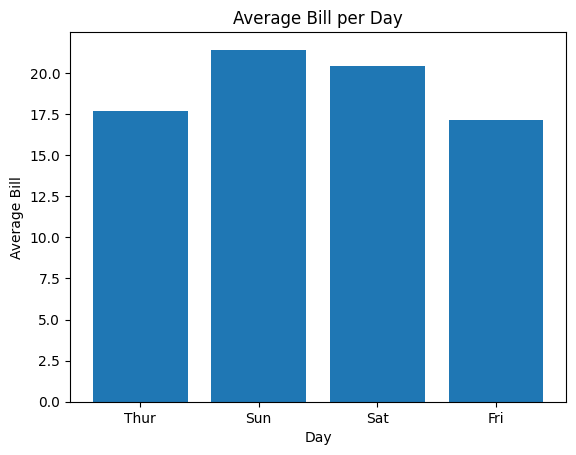

In [14]:
import matplotlib.pyplot as plt

df_pd = df_group.toPandas()

plt.figure()
plt.bar(df_pd['day'], df_pd['avg(total_bill)'])
plt.xlabel("Day")
plt.ylabel("Average Bill")
plt.title("Average Bill per Day")
plt.show()

## Step 15: Distribution of Total Bill

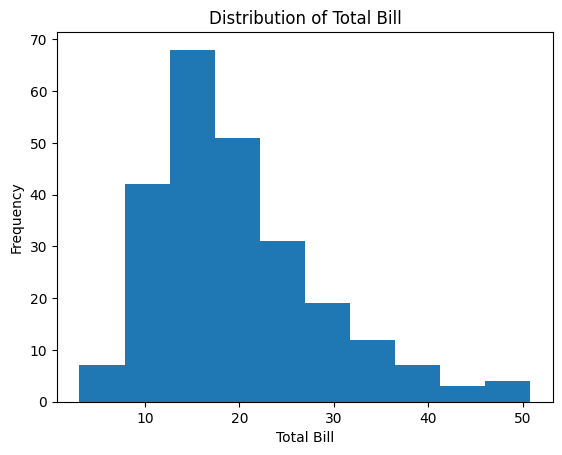

In [15]:
df_pd2 = df.toPandas()

plt.figure()
plt.hist(df_pd2['total_bill'], bins=10)
plt.xlabel("Total Bill")
plt.ylabel("Frequency")
plt.title("Distribution of Total Bill")
plt.show()

## Step 16: Tip vs Total Bill

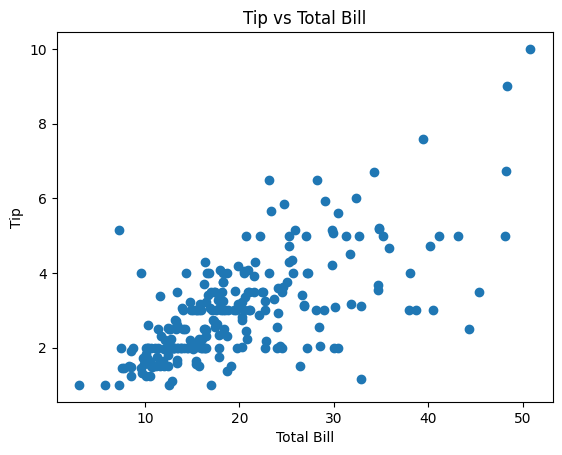

In [16]:
plt.figure()
plt.scatter(df_pd2['total_bill'], df_pd2['tip'])
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("Tip vs Total Bill")
plt.show()

## Step 17: Gender Distribution

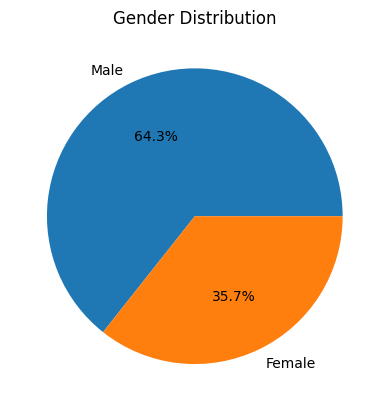

In [17]:
gender_count = df_pd2['sex'].value_counts()

plt.figure()
plt.pie(gender_count, labels=gender_count.index, autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()

## Step 18: Correlation Analysis (Heatmap)

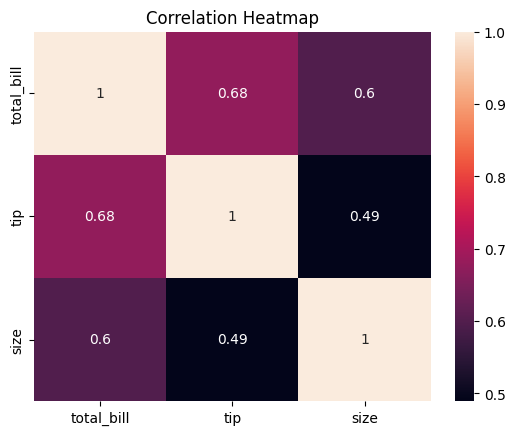

In [18]:
import seaborn as sns

numeric_df = df_pd2.select_dtypes(include=['number'])

plt.figure()
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Conclusion
The project demonstrates the effectiveness of Apache Spark in distributed data processing.
Parallel execution improves performance compared to single-core processing.